In [6]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

data_dir = r"C:\Users\bhagi\Documents\Cancer Classification\archive\melanoma_cancer_dataset\train"


In [7]:
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='binary',  # since benign vs malignant
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 9605 files belonging to 2 classes.


In [8]:
benign = len(os.listdir(os.path.join(data_dir, "benign")))
malignant = len(os.listdir(os.path.join(data_dir, "malignant")))

print("Benign:", benign)
print("Malignant:", malignant)

Benign: 5000
Malignant: 4605


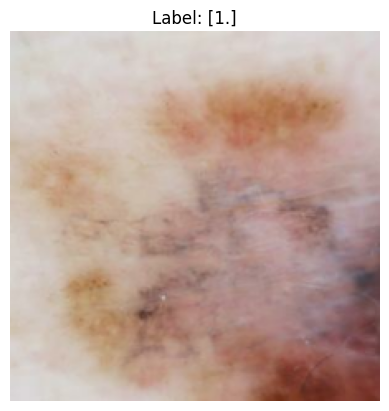

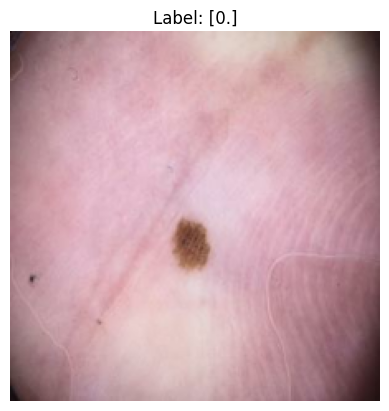

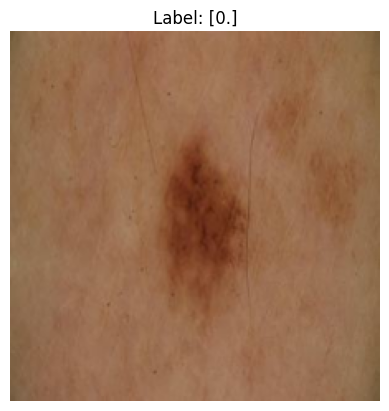

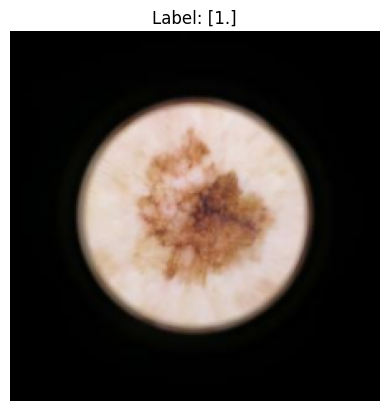

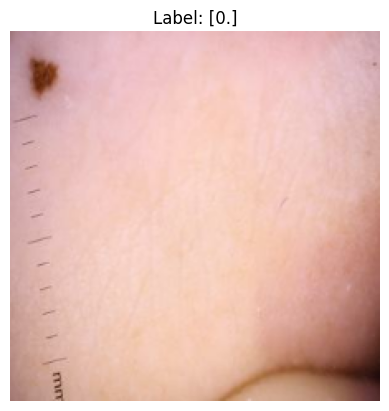

In [9]:
for images, labels in dataset.take(1):
    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
        plt.show()

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary'
)

Found 9605 files belonging to 2 classes.
Using 7684 files for training.
Found 9605 files belonging to 2 classes.
Using 1921 files for validation.


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # helps reduce overfitting

    layers.Dense(1, activation='sigmoid')  # binary output
])

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 189s 720ms/step - accuracy: 0.7327 - loss: 0.5417 - val_accuracy: 0.8272 - val_loss: 0.3711
Epoch 2/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 178s 738ms/step - accuracy: 0.8531 - loss: 0.3492 - val_accuracy: 0.8605 - val_loss: 0.3049
Epoch 3/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 165s 685ms/step - accuracy: 0.8691 - loss: 0.3092 - val_accuracy: 0.8636 - val_loss: 0.3118
Epoch 4/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 172s 713ms/step - accuracy: 0.8813 - loss: 0.2899 - val_accuracy: 0.8808 - val_loss: 0.2825
Epoch 5/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 176s 729ms/step - accuracy: 0.8868 - loss: 0.2742 - val_accuracy: 0.8860 - val_loss: 0.2667
Epoch 6/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 179s 741ms/step - accuracy: 0.8829 - loss: 0.2727 - val_accuracy: 0.8818 - val_loss: 0.2731
Epoch 7/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 170s 706ms/step - accuracy: 0.8898 - loss: 0.2599 - val_accuracy: 0.8761 - val_loss: 0.2851
Epoch 8/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 171s 709ms/step - accuracy: 0.8917 -

In [15]:
model.evaluate(val_ds)

61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.8860 - loss: 0.2667


[0.26671773195266724, 0.8859968781471252]

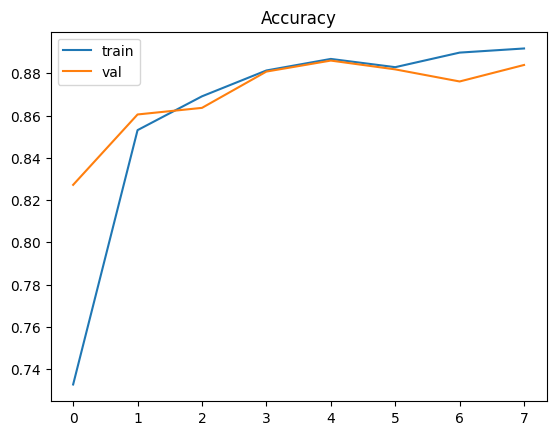

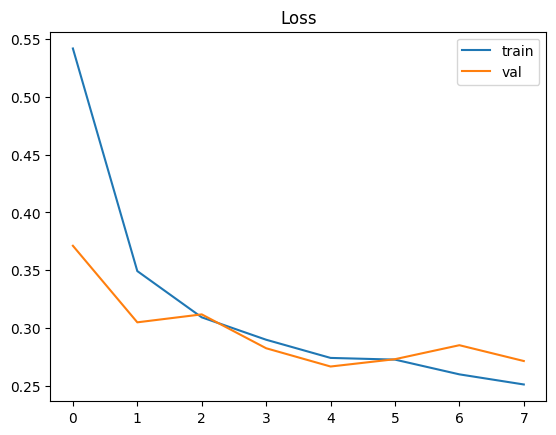

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [22]:
model.save("cnn_model.keras")

In [24]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model("cnn_model.keras")

C:\Users\bhagi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [29]:
def predict_image(img_path):
    # load image
    img = image.load_img(img_path, target_size=(224, 224))

    # convert to array
    img_array = image.img_to_array(img)

    # normalize (must match training)
    img_array = img_array / 255.0

    # add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    prediction = model.predict(img_array)[0][0]

    # result
    if prediction > 0.5:
        print("Prediction: Malignant (Cancerous)")
    else:
        print("Prediction: Benign (Non-cancerous)")

    print("Confidence:", float(prediction))

predict_image(r"C:\Users\bhagi\Documents\Cancer Classification\archive\melanoma_cancer_dataset\train\benign\melanoma_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Benign (Non-cancerous)
Confidence: 0.007441593334078789
